# Stock Analysis

## Setup

In [1]:
%%time
import warnings
warnings.filterwarnings("ignore")

!python3 -m pip install --upgrade pip

CPU times: user 8.15 ms, sys: 11 ms, total: 19.2 ms
Wall time: 1.04 s


### OSS libraries install

In [2]:
%pip install pandas numpy nbformat plotly  ipython-autotime --use-deprecated=legacy-resolver


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
%load_ext autotime

time: 68 μs (started: 2025-07-31 13:23:00 -07:00)


## Analysis

## load data

In [4]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("./stock_AAPL.csv")

df.head()

,date,open,high,low,close,volume
0,1980-12-12,0.0986,0.0991,0.0986,0.0986,1609186
1,1980-12-15,0.0939,0.0939,0.0935,0.0935,603256
2,1980-12-16,0.0871,0.0871,0.0866,0.0866,362690
3,1980-12-17,0.0887,0.0892,0.0887,0.0887,296358
4,1980-12-18,0.0914,0.0918,0.0914,0.0914,252061


time: 254 ms (started: 2025-07-31 13:23:00 -07:00)


In [5]:
df.describe()

,open,high,low,close,volume
count,11248.000000,11248.000000,11248.000000,11248.000000,1.124800e+04
mean,25.848303,26.130608,25.582492,25.869133,1.861808e+07
std,53.726168,54.312404,53.188167,53.780207,2.715378e+07
min,0.038200,0.038200,0.037700,0.037700,0.000000e+00
25%,0.244575,0.250250,0.239500,0.244750,1.190357e+06
50%,0.460950,0.468100,0.454600,0.462200,5.874732e+06
75%,20.310100,20.414475,20.111025,20.278850,2.604411e+07
max,257.569000,259.474000,257.010000,258.397000,3.239002e+08


time: 6.72 ms (started: 2025-07-31 13:23:00 -07:00)


In [15]:
import plotly.graph_objs as go

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=df["date"],
            y=df["high"],
            z=df["low"],
            mode="markers",
            marker=dict(
                size=3,
                color=df["high"],  # set color to high value
                colorscale="Viridis",
                opacity=0.8,
            ),
        )
    ]
)

fig.update_layout(
    scene=dict(xaxis_title="Date", yaxis_title="Open", zaxis_title="High"),
    title="3D Plot of Open vs High based on Date",
)

fig.update_layout(width=1600, height=900)

fig.show()

time: 20.7 ms (started: 2025-07-31 13:27:16 -07:00)


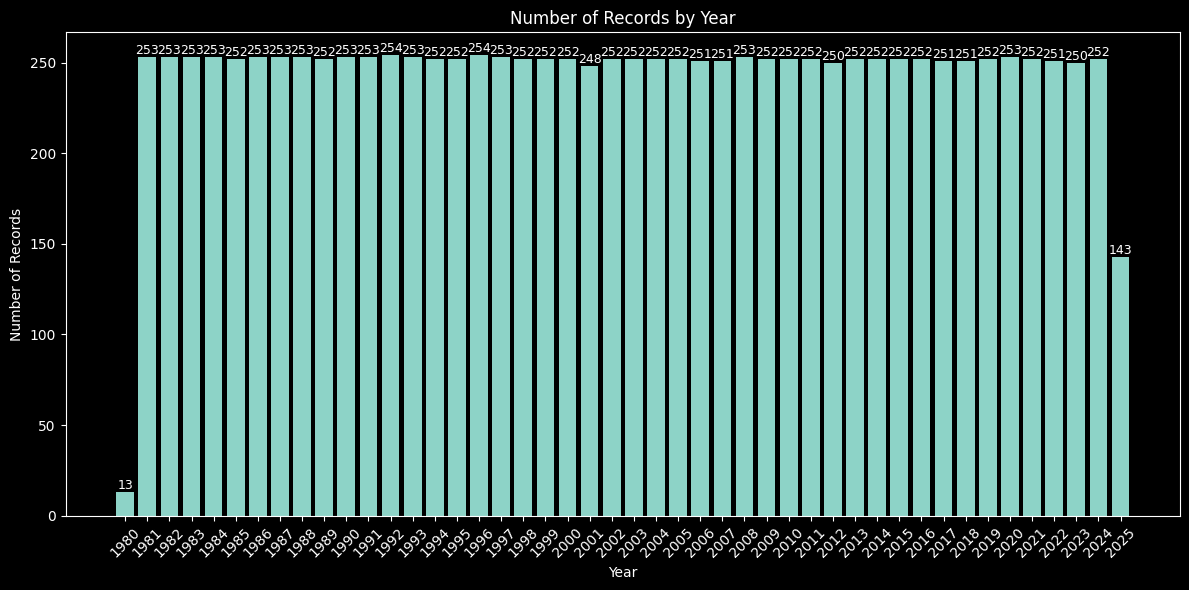

time: 156 ms (started: 2025-07-31 13:28:57 -07:00)


In [ ]:
import matplotlib.pyplot as plt

# Convert 'date' column to datetime if not already
df["date"] = pd.to_datetime(df["date"])

# Extract year from date
df["year"] = df["date"].dt.year

# Count number of records per year
year_counts = df["year"].value_counts().sort_index()

# Plot number of records per year
plt.figure(figsize=(12, 6))
plt.bar(year_counts.index, year_counts.values)
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.title("Number of Records by Year")
plt.xticks(year_counts.index, rotation=45)

# Add count labels on top of each bar
for i, count in enumerate(year_counts.values):
    plt.text(
        year_counts.index[i], count, str(count), ha="center", va="bottom", fontsize=9
    )
plt.tight_layout()
plt.show()